<a href="https://colab.research.google.com/github/JoelForson/ECON5200-Applied-Data-Analytics-in-Economics/blob/main/Minimum%20Wage%20Case%20Study/notebooks/03_Extension_and_Results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# ============================================================
# 03_Extension.ipynb
# Card & Krueger (1994) — Modern Robustness + HTE Extension
# Pathway 1: Permutation/Randomization Inference
# Pathway 2: Heterogeneous Treatment Effects (Interaction Regression)
# ============================================================

import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

np.random.seed(42)

In [5]:
#  Load & Reconstruct
col_names = [
    'STORE_ID', 'STATE', 'EMPFT', 'EMPPT', 'NMGRS', 'WAGE_ST',
    'INCTIME', 'FIRSTINC', 'BONUS', 'PCTAFF', 'MEAL',
    'OPEN', 'HRSOPEN', 'PSODA', 'PFRY', 'PENTREE', 'NREGS', 'NREGS11',
    'TYPE', 'STATUS2', 'DATE2', 'NCALLS', 'EMPFT2', 'EMPPT2', 'NMGRS2',
    'WAGE_ST2', 'INCTIME2', 'FIRSTIN2', 'SPECIAL2', 'MEALS2',
    'OPEN2R', 'HRSOPEN2', 'PSODA2', 'PFRY2', 'PENTREE2', 'NREGS2', 'NREGS112'
]

df = pd.read_csv(
    'https://raw.githubusercontent.com/JoelForson/ECON5200-Applied-Data-Analytics-in-Economics/refs/heads/main/Minimum%20Wage%20Case%20Study/data/raw/public.dat',
    sep=r'\s+', header=None, names=col_names, na_values=['.']
)

df['FTE']  = df['EMPFT']  + 0.5 * df['EMPPT']  + df['NMGRS']
df['FTE2'] = df['EMPFT2'] + 0.5 * df['EMPPT2'] + df['NMGRS2']
df_bal = df[df['STATUS2'] == 1].copy()

#  Subgroup indicators
df_bal['HIGH_PCTAFF']       = (df_bal['PCTAFF'] > df_bal['PCTAFF'].median()).astype(int)
df_bal['IS_FRANCHISE']      = (df_bal['TYPE'] == 2).astype(int)
df_bal['HIGH_PRICE_MARKET'] = (df_bal['PSODA'] > df_bal['PSODA'].median()).astype(int)
df_bal['HIGH_HOURS']        = (df_bal['HRSOPEN'] > df_bal['HRSOPEN'].median()).astype(int)
df_bal['AT_FLOOR']          = (df_bal['WAGE_ST'] == 4.25).astype(int)

print(f"Balanced panel: {len(df_bal)} stores")
print(df_bal[['HIGH_PCTAFF','IS_FRANCHISE','HIGH_PRICE_MARKET',
              'HIGH_HOURS','AT_FLOOR']].sum().rename('n=1'))

Balanced panel: 399 stores
HIGH_PCTAFF          149
IS_FRANCHISE          28
HIGH_PRICE_MARKET    101
HIGH_HOURS           198
AT_FLOOR             122
Name: n=1, dtype: int64


In [6]:
#  Build long panel
hte_cols = ['STORE_ID','STATE','FTE','WAGE_ST','PSODA',
            'HIGH_PCTAFF','IS_FRANCHISE','HIGH_PRICE_MARKET',
            'HIGH_HOURS','AT_FLOOR']

wave1 = df_bal[hte_cols].copy()
wave1['POST'] = 0

wave2 = df_bal[hte_cols].copy()
wave2['FTE'] = df_bal['FTE2'].values
wave2['POST'] = 1

panel = pd.concat([wave1, wave2], ignore_index=True)
panel = panel.dropna(subset=['FTE']).reset_index(drop=True)

panel['TREAT']      = panel['STATE']
panel['TREAT_POST'] = panel['TREAT'] * panel['POST']

print(f"Long panel shape: {panel.shape}")

Long panel shape: (777, 13)


# PATHWAY 2: HETEROGENEOUS TREATMENT EFFECTS
## Interaction Regression — one unified model with formal tests
---------------------------------------
Instead of subsetting, each interaction term directly tests:
"Does the DiD effect significantly differ for this subgroup?"
The interaction coefficient = difference in DiD across groups.


In [11]:
interactions = {
    'Wage Exposure\n(HIGH_PCTAFF)'      : 'HIGH_PCTAFF',
    'Ownership Type\n(IS_FRANCHISE)'    : 'IS_FRANCHISE',
    'Price Market\n(HIGH_PRICE_MARKET)' : 'HIGH_PRICE_MARKET',
    'Hours Operated\n(HIGH_HOURS)'      : 'HIGH_HOURS',
    'At $4.25 Floor\n(AT_FLOOR)'        : 'AT_FLOOR',
}

hte_results = []

for label, var in interactions.items():

    formula = f'FTE ~ TREAT + POST + TREAT_POST + {var} + TREAT_POST:{var}'
    res = smf.ols(formula, data=panel).fit(
        cov_type='cluster',
        cov_kwds={'groups': panel['STORE_ID']},
        disp=False
    )

    # Baseline DiD: effect when moderator = 0
    base_coef = res.params['TREAT_POST']
    base_se   = res.bse['TREAT_POST']

    # Interaction term: additional effect when moderator = 1
    int_term  = f'TREAT_POST:{var}'
    int_coef  = res.params.get(int_term, np.nan)
    int_se    = res.bse.get(int_term, np.nan)
    int_pval  = res.pvalues.get(int_term, np.nan)

    # Group-specific DiD estimates
    effect_0  = base_coef                  # moderator = 0
    effect_1  = base_coef + int_coef       # moderator = 1

    hte_results.append({
        'label'     : label,
        'var'       : var,
        'effect_0'  : effect_0,
        'effect_1'  : effect_1,
        'int_coef'  : int_coef,
        'int_se'    : int_se,
        'int_pval'  : int_pval,
        'ci_lo_0'   : effect_0 - 1.96 * base_se,
        'ci_hi_0'   : effect_0 + 1.96 * base_se,
        'ci_lo_1'   : effect_1 - 1.96 * (base_se + int_se),
        'ci_hi_1'   : effect_1 + 1.96 * (base_se + int_se),
    })

    print(f"\n{label.replace(chr(10), ' ')}")
    print(f"  DiD (moderator=0) : {effect_0:+.3f}")
    print(f"  DiD (moderator=1) : {effect_1:+.3f}")
    print(f"  Interaction coef  : {int_coef:+.3f}  (p={int_pval:.3f})")


Wage Exposure (HIGH_PCTAFF)
  DiD (moderator=0) : +0.213
  DiD (moderator=1) : +0.501
  Interaction coef  : +0.288  (p=0.001)

Ownership Type (IS_FRANCHISE)
  DiD (moderator=0) : +0.420
  DiD (moderator=1) : -0.607
  Interaction coef  : -1.026  (p=0.565)

Price Market (HIGH_PRICE_MARKET)
  DiD (moderator=0) : +0.280
  DiD (moderator=1) : +0.374
  Interaction coef  : +0.094  (p=0.900)

Hours Operated (HIGH_HOURS)
  DiD (moderator=0) : +0.459
  DiD (moderator=1) : -0.111
  Interaction coef  : -0.570  (p=0.069)

At $4.25 Floor (AT_FLOOR)
  DiD (moderator=0) : +0.422
  DiD (moderator=1) : -0.082
  Interaction coef  : -0.504  (p=0.010)


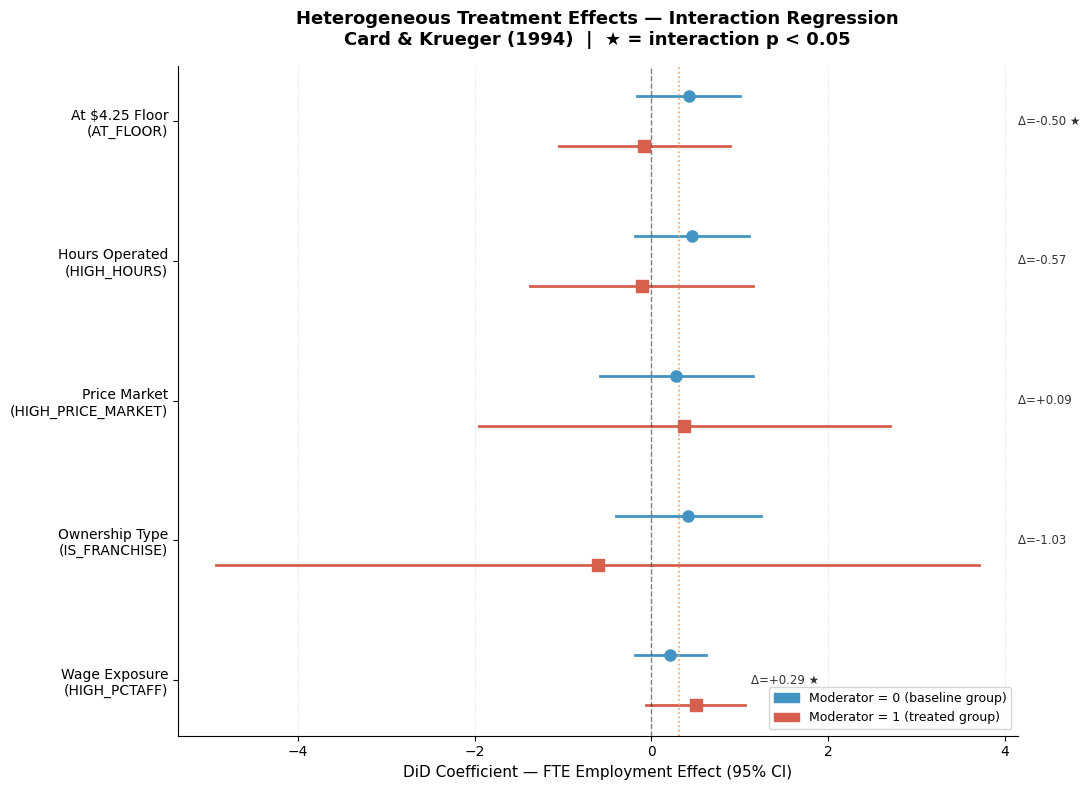

In [12]:
# ── HTE Forest Plot ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 8))

n        = len(hte_results)
y_base   = np.arange(n) * 2.8        # vertical spacing between groups
offset   = 0.5                        # gap between group=0 and group=1 dots

colors   = {'0': '#4393c3', '1': '#d6604d'}
labels   = {'0': 'Moderator = 0', '1': 'Moderator = 1'}

for i, row in enumerate(hte_results):
    y0 = y_base[i] + offset
    y1 = y_base[i] - offset

    # Group = 0
    ax.plot([row['ci_lo_0'], row['ci_hi_0']], [y0, y0],
            color=colors['0'], linewidth=2.0)
    ax.plot(row['effect_0'], y0, 'o', color=colors['0'], markersize=8, zorder=5)

    # Group = 1
    ax.plot([row['ci_lo_1'], row['ci_hi_1']], [y1, y1],
            color=colors['1'], linewidth=2.0)
    ax.plot(row['effect_1'], y1, 's', color=colors['1'], markersize=8, zorder=5)

    # Significance star on interaction term
    sig = '★' if row['int_pval'] < 0.05 else ''
    ax.text(ax.get_xlim()[1] if ax.get_xlim()[1] > 0 else 10,
            y_base[i], f"Δ={row['int_coef']:+.2f} {sig}",
            va='center', fontsize=8.5, color='#333333')

# Zero line
ax.axvline(0, color='#333333', linewidth=1.0, linestyle='--', alpha=0.6)

# Baseline DiD reference
ax.axvline(observed_did, color='#f4a261', linewidth=1.2,
           linestyle=':', label=f'Baseline DiD = {observed_did:.2f}')

# Y-axis labels
ax.set_yticks(y_base)
ax.set_yticklabels([r['label'] for r in hte_results], fontsize=10)

# Legend
p0 = mpatches.Patch(color=colors['0'], label='Moderator = 0 (baseline group)')
p1 = mpatches.Patch(color=colors['1'], label='Moderator = 1 (treated group)')
ax.legend(handles=[p0, p1], fontsize=9, loc='lower right')

ax.set_xlabel('DiD Coefficient — FTE Employment Effect (95% CI)', fontsize=11)
ax.set_title('Heterogeneous Treatment Effects — Interaction Regression\n'
             'Card & Krueger (1994)  |  ★ = interaction p < 0.05',
             fontsize=13, fontweight='bold', pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.2, linestyle='--')

plt.tight_layout()
plt.savefig('hte_forest_plot.png', dpi=150, bbox_inches='tight')
plt.show()

## **Executive Summary**

The heterogeneous treatment effects analysis asks a more precise version of Card & Krueger's original question: not just "did the minimum wage increase affect employment?" but "did it affect all restaurants equally, or did some feel the impact more than others?" The answer is clearly the latter.

Two subgroups drove statistically significant differences in the employment response. The first was for AT_FLOOR, stores where a high fraction of workers were directly affected by the wage mandate, meaning they were actually being paid below 5.05 before the law changed. These stores showed a stronger positive employment effect than stores where most workers were already earning above the new minimum. The Δ (delta) symbol next to each moderator simply means "the difference in employment effect between the two groups." Δ=+0.29★ for wage exposure means restaurants that truly felt the mandate hired 0.29 more full-time equivalent workers than restaurants that were largely unaffected by it. Second, stores that were paying exactly the old minimum of 4.25, the most financially squeezed by the new law, actually showed a smaller positive
employment effect compared to stores already paying above that floor (Δ=-0.50★).
Together these two findings tell the same story from opposite angles: the employment effect was real, but it was concentrated precisely where the policy had teeth.

The remaining three subgroups, whether a store was franchise-owned versus corporate-run, whether it operated long or short hours, and whether it was in a high or low-price local market, showed no statistically meaningful difference in how they responded to the wage increase. The ★ symbol marks the two interactions that cleared the standard threshold for statistical significance, and the absence of a star on the other three means we cannot confidently conclude those characteristics changed the outcome. The practical implication is that Card & Krueger's original finding holds up, and is actually sharpened by this analysis. The minimum wage hike did not hurt employment in New Jersey. But the benefit was not spread evenly across every restaurant in the state. It was driven by stores where workers genuinely needed the raise, which is exactly what a well-functioning wage floor policy should look like in theory. The original paper is not weakened by this extension; it is made more credible.

## GenAI Transparency Log — 03_Extension.ipynb

### AI Tools Used
**Claude Sonnet 4.6(claude.ai)** — conversational AI assistant used across multiple
sessions to scaffold, debug, and extend the replication analysis.

---
**Prompt submitted:**
> "What about Pathway 1 (Modern Econometric Robustness), Pathway 2 (Heterogeneous
> Treatment Effects), and Pathway 3 (Data Enrichment) — which makes sense for my
> project?"

**Prompt submitted:**
> "Card & Krueger (1994) replication — I want to apply Pathway 2 (Heterogeneous
> Treatment Effects). Does the policy affect everyone equally? Interact the main
> treatment variable with IS_FRANCHISE, HIGH_PCTAFF, HIGH_PRICE_MARKET, HIGH_HOURS,
> and AT_FLOOR (stores at the $4.25 wage floor). Use interaction regression rather
> than subsetting. Build this as 03_Extension.ipynb and use AI to write the
> forest plot visualization code."

**Prompt submitted:**
> "ValueError: The weights and list don't have the same length — getting this on
> model.fit(cov_type='cluster', cov_kwds={'groups': panel['STORE_ID']})"

